# **Agrupamento de Textos de Notícias em Categorias Distintas**

Tutor: **Alessandro Brassanini**

Projeto desenvolvido em equipe (4 integrantes) como trabalho de conclusão do curso de Big Data.


### 1. **Introdução e Contexto do Projeto**
#### **Objetivo**
O objetivo central deste projeto é explorar e aplicar técnicas de machine learning não supervisionado para agrupar automaticamente artigos de notícias sem categorias predefinidas. Através da análise de texto, o modelo proposto buscará identificar e organizar padrões latentes nos dados, visando descobrir agrupamentos naturais e intuitivos que facilitam a categorização e a análise posterior dos artigos.

#### **Importância e Aplicabilidade**
O volume crescente de dados textuais disponíveis on-line apresenta desafios significativos para a organização, recuperação e análise de informações. A utilização de técnicas avançadas de processamento de linguagem natural (PLN) e algoritmos de clusterização pode transformar radicalmente a maneira como lidamos com esses dados, possibilitando a automatização de tarefas como a curadoria de conteúdo, análise de sentimentos, e detecção de tendências, especialmente em campos como o jornalismo digital e o monitoramento de mídias sociais.

#### **Metodologia**
Este projeto irá implementar e comparar os três tipos mais utilizados de algoritmos de clustering, incluindo KMeans, DBSCAN e Clustering Aglomerativo, para determinar o método mais eficaz em termos de agrupamento de textos. A seleção do algoritmo ideal será guiada pela análise dos scores de Silhouette, que avaliam a coesão dentro dos clusters e a separação entre eles, fornecendo uma medida quantitativa da qualidade da clusterização.

#### **Potenciais Descobertas**
Espera-se que a aplicação dessas técnicas de clusterização não supervisionada revele categorias naturais dentro do conjunto de dados, proporcionando insights sobre temas recorrentes e preferências editoriais, além de facilitar a organização dos dados de maneira mais intuitiva e acessível. Essas descobertas poderão não apenas enriquecer nossa compreensão das dinâmicas de conteúdo online mas também fundamentar futuras investigações e aplicações que dependam da categorização eficaz e automática de grandes volumes de texto.

#### **Especificações Técnicas**

 **Dataset de noticias (wikinoticias) do PlosOne**

O dataset utilizado no projeto é proveniente do WikiNoticias, disponível através do PlosOne. Este recurso é amplamente empregado para análises de textos, mineração de dados e pesquisas em aprendizado de máquina.

O WikiNoticias é derivado do conteúdo da Wikinews, uma fonte de notícias colaborativa e aberta que faz parte da família Wikimedia. Os datasets são organizados por categorias, refletindo a classificação de notícias da Wikinews, como política, esportes, tecnologia, saúde, entre outras. Esta estrutura facilita a análise de diferentes tópicos e permite uma segmentação eficiente dos dados para diversas aplicações.

O metodo de download e extração de dados, estão na referência número **11**

 **Formato**
Arquivos em formato JSON

**Descrição das Features**
pageid: id da página
tittle: título da notícia
dates: data de publicação
body: corpo do texto
category: categoria da notícia

 **Tipo de dados**
Object (Objetos)

 **Métodos de Pré-processamento**

- Obtenção de dados;

- Converter o texto para letras minúsculas;

- Remover stopwords;

- Remover pontuações;

- Lematizar (ato de representar as palavras através do infinitivo dos verbos e masculino singular dos substantivos e adjetivos) cada palavra.

**Modo de Aprendizado**
Não Supervisionado.

**Algoritmos Avaliados**
KMeans, DBScan, Agglomerative.

**Método de Avaliação**
Silhouette Score

**Modelo**
Será aplicado o modelo Agglomerative.


### 2. Configuração e Importação de Bibliotecas

In [ ]:
import os

# Instala o pacote de idioma pt_BR para locale library
!/usr/share/locales/install-language-pack pt_BR.utf8
!dpkg-reconfigure locales

# Reinicia os processos de python e carrega os novos pacotes
os.kill(os.getpid(), 9)

# Após a reinicialização, as próximas células podem ser executadas normalmente

Generating locales (this might take a while)...
Generation complete.
dpkg-trigger: error: must be called from a maintainer script (or with a --by-package option)

Type dpkg-trigger --help for help about this utility.
Generating locales (this might take a while)...
  en_US.UTF-8... done
  pt_BR.UTF-8... done
Generation complete.


In [ ]:
 !pip install spacy -q
 !python -m spacy download pt_core_news_sm -q

✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import locale
import numpy as np
import pandas as pd
import requests

import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

import plotly.express as px
import matplotlib.pyplot as plt
import plotly.graph_objects as go


from collections import Counter
import seaborn as sns


### 3. Carregamento e Preparação dos Dados

In [ ]:
def fetch_data(url: str) -> pd.DataFrame:
    """
    Carrega dados de notícias a partir de um arquivo JSON disponibilizado via URL.

    Parameters
    ----------
    url : str
        URL do arquivo JSON.

    Returns
    -------
    pd.DataFrame
        DataFrame contendo os dados das notícias.
    """
    response = requests.get(url)
    response.raise_for_status()
    data = pd.DataFrame(response.json())
    return data.drop(columns=['category'], errors='ignore')


In [ ]:
file_path = 'https://www.dropbox.com/scl/fi/61u504jjs02frhzfjt1te/wikinews_categories.json?rlkey=j9ovkjolliaxzkzuj0u6bea1n&st=chjm0z95&dl=1'

df = fetch_data(file_path)

print(df.info())

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9135 entries, 0 to 9134
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   pageid  9135 non-null   object
 1   title   9135 non-null   object
 2   dates   9135 non-null   object
 3   body    9135 non-null   object
dtypes: object(4)
memory usage: 285.6+ KB
None


,pageid,title,dates,body
0,1037,Subida da esquerda em Portugal,[20 de fevereiro de 2005],"Hoje, as eleições legislativas, em Portugal, d..."
1,1148,Governo libanês renuncia em meio a protestos,[ 4 de março de 2005 ],right \n\nO governo do Líbano renunciou 28 de ...
2,1211,Italiana libertada é ferida próximo a posto de...,[5 de março de 2005],O carro em que viajava a jornalista italiana ...
3,1220,Óleo de girassol previne infecção em recém-nas...,[5 de março de 2005],Bebês que nascem com peso baixo podem ser pro...
4,1225,Rainha Elizabeth torna Bill Gates cavaleiro,[6 de março de 2005],200px|right|thumb|Bill Gates durante fórum de ...


Esta seção do código é dedicada à conversão de strings de data, que estão no formato local português, para objetos datetime do PythoN.

In [ ]:
# Configura locale para português para reconhecer nomes de meses em português
locale.setlocale(locale.LC_TIME, 'pt_BR.utf8')

def parse_portuguese_date(date_list):
    """
    Converte uma data em formato português para um objeto datetime.

    Parameters
    ----------
    date_list : list
        Lista contendo uma string de data no formato "20 de fevereiro de 2005".

    Returns
    -------
    datetime64 or NaT
        Objeto datetime convertido ou NaT se a conversão falhar.

    Examples
    --------
    >>> parse_portuguese_date(["20 de fevereiro de 2005"])
    2005-02-20
    """
    if not date_list or pd.isna(date_list[0]):
        return pd.NaT

    date_str = date_list[0].strip()
    # Remove espaços duplos e corrige o formato da data
    date_str = ' '.join(date_str.split())

    try:
        return pd.to_datetime(date_str, format='%d de %B de %Y', errors='coerce')
    except ValueError as e:
        print(f"Erro ao converter a data: {date_str} | Erro: {str(e)}")
        return pd.NaT


In [ ]:
%%time
# Aplica a função no DataFrame
df['date'] = df['dates'].apply(parse_portuguese_date)


CPU times: user 575 ms, sys: 4.77 ms, total: 580 ms
Wall time: 590 ms


Após a conversão e limpeza dos dados, é criado um gráfico de série temporal que mostra o número de artigos publicados por ano. Este gráfico ajuda a identificar tendências, padrões sazonais ou quaisquer anomalias nos dados, como picos inesperados de atividades ou lacunas nas publicações.


In [ ]:
# Análise temporal dos artigos

def analyze_articles_per_year_plotly(df: pd.DataFrame):
    """
    Analisa e visualiza a quantidade de artigos por ano com Plotly,
    identificando anos com ausência de artigos.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame que contém as colunas de datas dos artigos.

    Returns
    -------
    None
    """
    df=df.copy()

    # Converte as datas para o tipo datetime e extrai o ano
    df['year'] = pd.to_datetime(df['date']).dt.year
    df = df.dropna(subset=['year'])  # Removendo entradas NaN
    df['year'] = df['year'].astype(int)

    # Conta os artigos por ano
    articles_per_year = df['year'].value_counts().sort_index()

    # Verifica anos sem artigos
    year_range = range(df['year'].min(), df['year'].max() + 1)
    missing_years = [year for year in year_range if year not in articles_per_year.index]

    # Prepara os dados para plotagem
    data = articles_per_year.reset_index()
    data.columns = ['Ano ', 'Número de Artigos ']

    # Cria o gráfico com Plotly
    fig = px.bar(data, x='Ano ', y='Número de Artigos ', text='Número de Artigos ')
    fig.update_layout(
        title='Número de Artigos por Ano',
        xaxis_title='Ano',
        yaxis_title='Quantidade de Artigos',
        xaxis=dict(tickmode='linear', type='category'),
        plot_bgcolor='white'
    )
    fig.update_xaxes(tickvals=data['Ano '].tolist())
    fig.show()

    return articles_per_year, missing_years

articles_per_year, missing_years = analyze_articles_per_year_plotly(df)


### 4. Carregamento das Stopwords Personalizadas

In [ ]:
def load_stopwords(url: str) -> set:
    """
    Carrega um conjunto de stopwords personalizadas de um arquivo remoto.

    Parameters
    ----------
    url : str
        URL do arquivo de texto contendo stopwords.

    Returns
    -------
    set
        Conjunto de stopwords.
    """
    response = requests.get(url)
    response.raise_for_status()
    return set(response.text.split())


In [ ]:
stopwords_url = 'https://www.dropbox.com/scl/fi/23qh0fc2smnw0tu7ni7ij/stopwords.txt?rlkey=4nayfklpal3umk4xk2ccygvkz&st=xui2w68n&dl=1'
stopwords = load_stopwords(stopwords_url)



### 5. Preprocessamento dos Textos

In [ ]:
nlp = spacy.load("pt_core_news_sm")

In [ ]:

def preprocess_text(texts: pd.Series, additional_stopwords: set) -> pd.Series:
    """
    Processa textos para lematização, remoção de stopwords e retorna os textos processados,
    excluindo palavras não informativas como preposições e artigos.

    Parameters
    ----------
    texts : pd.Series
        Série do pandas contendo os textos a serem processados.
    additional_stopwords : set
        Conjunto adicional de stopwords para remover dos textos.

    Returns
    -------
    pd.Series
        Série do pandas com os textos processados.

    Notes
    -----
    A função amplia a filtragem de palavras não informativas, além de remover stopwords e lematizar.
    """
    # Combina as stopwords padrão do spaCy com stopwords adicionais fornecidas.
    all_stopwords = nlp.Defaults.stop_words.union(additional_stopwords)

    processed_texts = []

    for doc in nlp.pipe(texts.astype(str), batch_size=50):
        filtered_sentence = []
        for token in doc:
            lemma = token.lemma_.lower().strip()
            # Remove palavras com base em lematização e verifica se não são parte das stopwords
            if lemma not in all_stopwords and token.is_alpha and token.pos_ not in ['ADP', 'DET', 'CONJ']:
                filtered_sentence.append(lemma)

        processed_texts.append(" ".join(filtered_sentence))

    return pd.Series(processed_texts)


In [ ]:
%%time

# Cria o campo preprocessado e adiciona as palavras que frequentemente são irrelevantes mas não são stopwords

df['processed_text'] = preprocess_text(df['body'], {'ano',
 'ao', 'cf', 'class', 'com', 'da',
 'de', 'dever', 'dia', 'dias', 'disse',
 'do', 'durante', 'e', 'o','estados', 'fc',
 'fonte', 'fontes', 'g', 'haver', 'hoje',
 'j', 'no', 'osj', 'p', 'para', 'país', 'pc',
 'pessoa', 'pf', 'pts', 'stade', 'state',
 'um', 'uma', 'unidos', 'wikinotícias'})

CPU times: user 4min 59s, sys: 2.56 s, total: 5min 1s
Wall time: 5min 8s


### 6 Visualização das Palavras Mais Frequentes

In [ ]:
def plot_most_frequent_words(texts: pd.Series):
    """
    Plota as palavras mais frequentes nos textos processados.

    Parameters
    ----------
    texts : pd.Series
        Série de textos processados.

    Returns
    -------
    None
    """

    words = Counter(" ".join(texts).split())
    most_common_words = words.most_common(20)
    word_counts = pd.DataFrame(most_common_words, columns=['Word', 'Frequency'])

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Frequency', y='Word', data=word_counts)
    plt.title('Palavras mais frequentes')
    plt.xlabel('Frequência')
    plt.ylabel('Palavra')
    plt.show()




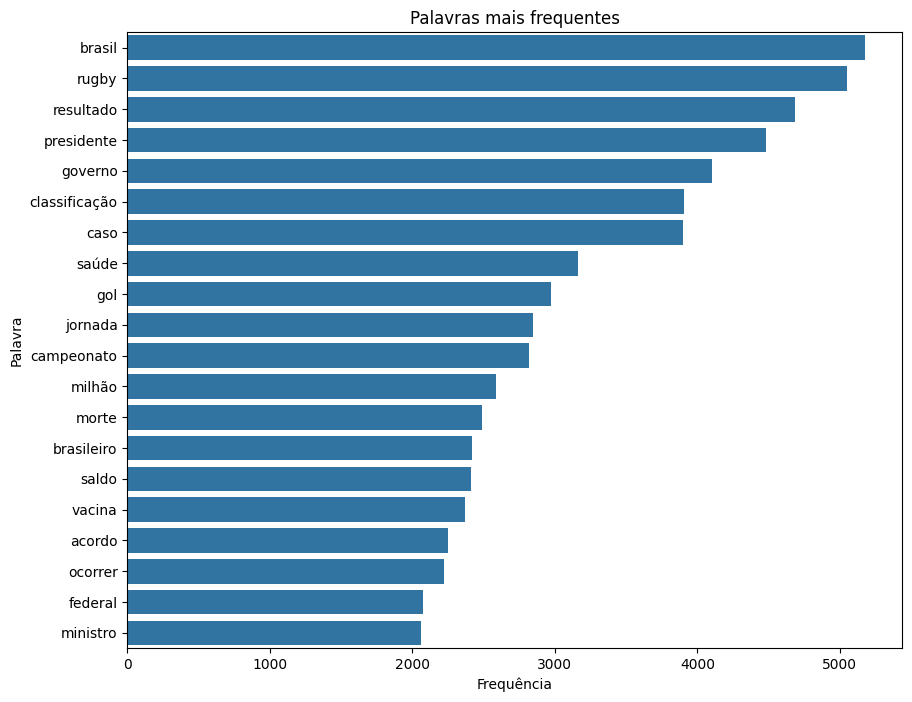

CPU times: user 797 ms, sys: 249 ms, total: 1.05 s
Wall time: 984 ms


In [ ]:
%%time
plot_most_frequent_words(df['processed_text'])


### 7. Vetorização usando TF-IDF

In [ ]:
def vectorize_texts(texts: list[str]) -> tuple:
    """
    Converte uma lista de textos pré-processados em uma matriz TF-IDF.

    Parameters
    ----------
    texts : list[str]
        Lista de textos a serem vetorizados.

    Returns
    -------
    tuple
        Tupla contendo a matriz TF-IDF e os nomes das características (features).
    """
    vectorizer = TfidfVectorizer(max_features=1000)
    tfidf_matrix = vectorizer.fit_transform(texts)
    return tfidf_matrix, vectorizer.get_feature_names_out()


In [ ]:
%%time
tfidf_matrix, features = vectorize_texts(df['processed_text'].tolist())


CPU times: user 1.1 s, sys: 3.03 ms, total: 1.11 s
Wall time: 1.15 s


### 8. Aplicação de Técnicas de Clustering e Comparação de Algoritmos

**Silhouette Score**: Métrica usada para avaliar a qualidade dos clusters formados por diferentes algoritmos de clustering. O Silhouette Score varia de -1 a +1, onde um valor alto indica que os clusters são bem compactos internamente e bem separados uns dos outros.


In [ ]:
def compare_clustering_algorithms(tfidf_matrix):
    """
    Aplica e compara diferentes algoritmos de clustering sobre a matriz TF-IDF.

    Parameters
    ----------
    tfidf_matrix : scipy.sparse.csr_matrix
        Matriz TF-IDF dos textos processados.

    Returns
    -------
    tuple
        Dicionário contendo os resultados de clustering para cada algoritmo e o próprio dicionário de algoritmos.
    """
    algorithms = {
        "KMeans": KMeans(n_clusters=5, n_init=10, random_state=42),
        "Agglomerative": AgglomerativeClustering(n_clusters=5),
        "DBSCAN": DBSCAN(eps=0.5, min_samples=5)
    }
    results = {}
    for name, algorithm in algorithms.items():
        data = tfidf_matrix.toarray() if isinstance(algorithm, AgglomerativeClustering) else tfidf_matrix
        labels = algorithm.fit_predict(data)
        silhouette_avg = silhouette_score(data, labels)
        results[name] = {'labels': labels, 'silhouette_score': silhouette_avg}

    return results, algorithms


In [ ]:
%%time
# Executa a função para obter o resultado dos clusters criando os objetos com os resultados dos cluster e algoritmos.

clustering_results, algorithms = compare_clustering_algorithms(tfidf_matrix)


CPU times: user 4min 1s, sys: 4.75 s, total: 4min 6s
Wall time: 4min 6s


In [ ]:
def plot_algorithms(names: list[str], scores: list[float]):
    """
    Plota um gráfico de barras com os Silhouette scores para cada algoritmo de clustering,
    incluindo anotações para melhor visualização dos resultados numéricos.

    Parameters
    ----------
    names : list[str]
        Nomes dos algoritmos de clustering utilizados.
    scores : list[float]
        Silhouette scores obtidos para cada algoritmo de clustering.

    Notes
    -----
    Silhouette scores variam de -1 a 1, onde valores mais altos indicam uma melhor definição de clusters.
    """
    fig, ax = plt.subplots()
    bars = ax.bar(names, scores, color=['blue', 'green', 'red'])
    ax.set_xlabel('Algoritmos de Clustering')
    ax.set_ylabel('Silhouette Score')
    ax.set_title('Comparação dos Silhouette Scores para Algoritmos de Clustering')

    # Adiciona anotações com os scores de Silhouette em cada barra
    for bar, score in zip(bars, scores):
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval, round(score, 4), ha='center', va='bottom', fontsize=8)

    plt.show()


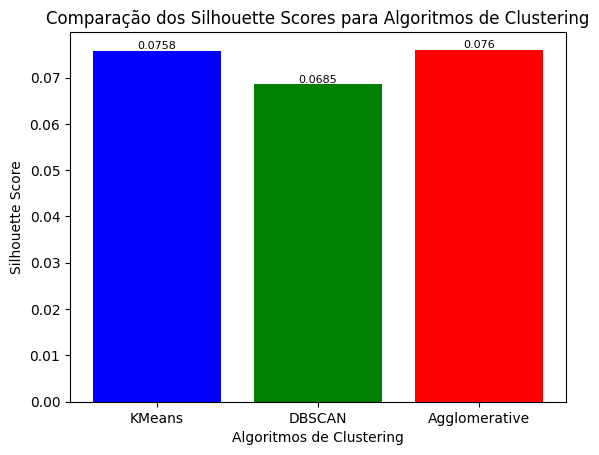


 ------------------------------------------------------------
 
KMeans: K-Means é um algoritmo de clustering que particiona os dados em K clusters, atribuindo cada ponto ao centroide mais próximo.
Silhouette Score: 0.0758

DBSCAN: DBSCAN é um algoritmo baseado em densidade que pode formar clusters de formas complexas, baseando-se em densidade de pontos.
Silhouette Score: 0.0685

Agglomerative: Clustering Aglomerativo é uma abordagem hierárquica que funde progressivamente os pares de
 clusters até que todos os clusters tenham sido combinados em um.
Silhouette Score: 0.0760



In [ ]:
# Dados dos algoritmos e seus scores para plotagem
algorithms = {
    "KMeans": "K-Means é um algoritmo de clustering que particiona os dados em K clusters, atribuindo cada ponto ao centroide mais próximo.",
    "DBSCAN": "DBSCAN é um algoritmo baseado em densidade que pode formar clusters de formas complexas, baseando-se em densidade de pontos.",
    "Agglomerative": "Clustering Aglomerativo é uma abordagem hierárquica que funde progressivamente os pares de\n clusters até que todos os clusters tenham sido combinados em um."
}

# Prepara dados para plotagem
names = list(algorithms.keys())
scores = [clustering_results[name]['silhouette_score'] for name in names]

plot_algorithms(names, scores)

print("\n", "---" * 20  )
print(" ")

# Imprime descrições e scores para cada algoritmo
for name in algorithms:
    print(f"{name}: {algorithms[name]}")
    print(f"Silhouette Score: {clustering_results[name]['silhouette_score']:.4f}\n")

### Identificação do Melhor Algoritmo de Clustering

In [ ]:
# Seleciona o algoritmo com o maior 'silhouette_score' do dicionário `clustering_results`. A função `max()` é aplicada com uma função lambda que acessa o 'silhouette_score' para cada algoritmo, determinando qual deles agrupou os dados de forma mais eficiente.
best_algorithm = max(clustering_results, key=lambda k: clustering_results[k]['silhouette_score'])

# Recupera os rótulos de clusters gerados pelo algoritmo com melhor desempenho. Esses rótulos indicam a que cluster cada ponto de dado foi atribuído, refletindo a estrutura de agrupamento encontrada pelo algoritmo.
labels = clustering_results[best_algorithm]['labels']

### 9. Visualização dos Clusters

In [ ]:
def map_cluster_labels(labels):
    """
    Mapeia os rótulos de cluster para nomes de categorias legíveis.

    Parameters
    ----------
    labels : array-like
        Lista ou array de rótulos de cluster.

    Returns
    -------
    list
        Lista de nomes de categorias correspondentes aos rótulos de cluster.
    """
    # Mapeia e rótulos de cluster para nomes legíveis
    cluster_labels = {
        0: "Política e Governo",
        1: "Economia e Negócios",
        2: "Ciência e Tecnologia",
        3: "Cultura e Entretenimento",
        4: "Saúde e Bem-estar"
    }
    return [f"{cluster_labels[label]} ({label})" for label in labels]


**Nota sobre os rótulos:** os nomes de categoria usados em `map_cluster_labels` (Política, Economia, etc.) foram atribuídos por inspeção manual dos termos mais frequentes de cada cluster, mostrados abaixo. Isso torna a atribuição auditável em vez de arbitrária.

In [ ]:
def top_terms_per_cluster(tfidf_matrix, labels, feature_names, n_terms: int = 10):
    """
    Mostra os termos com maior peso TF-IDF médio em cada cluster, para
    validar (ou corrigir) os nomes atribuídos manualmente em `map_cluster_labels`.

    Parameters
    ----------
    tfidf_matrix : scipy.sparse.csr_matrix
        Matriz TF-IDF dos textos processados.
    labels : array-like
        Rótulos de cluster atribuídos a cada documento.
    feature_names : array-like
        Nomes das features (termos) correspondentes às colunas da matriz TF-IDF.
    n_terms : int, default=10
        Número de termos mais representativos a exibir por cluster.

    Returns
    -------
    None
    """
    import numpy as np
    dense = tfidf_matrix.toarray()
    labels = np.array(labels)
    for cluster_id in sorted(set(labels)):
        mask = labels == cluster_id
        mean_tfidf = dense[mask].mean(axis=0)
        top_idx = mean_tfidf.argsort()[::-1][:n_terms]
        top_words = [feature_names[i] for i in top_idx]
        print(f"Cluster {cluster_id}: {', '.join(top_words)}")

top_terms_per_cluster(tfidf_matrix, labels, features)

In [ ]:
def plot_category_distribution(df):
    """
    Plota a distribuição das categorias de artigos usando um gráfico de barras.

    Parameters
    ----------
    df : DataFrame
        DataFrame que contém as categorias dos artigos.

    Returns
    -------
    None
    """
    category_counts = df['category_name'].value_counts().reset_index()
    category_counts.columns = ['category_name', 'counts']
    plt.figure(figsize=(12, 6))
    sns.barplot(x='category_name', y='counts', data=category_counts, palette='viridis', hue='category_name', legend=False)
    plt.xticks(rotation=45)
    plt.xlabel('Categorias')
    plt.ylabel('Número de Artigos')
    plt.title('Distribuição de Artigos por Categoria')
    plt.show()


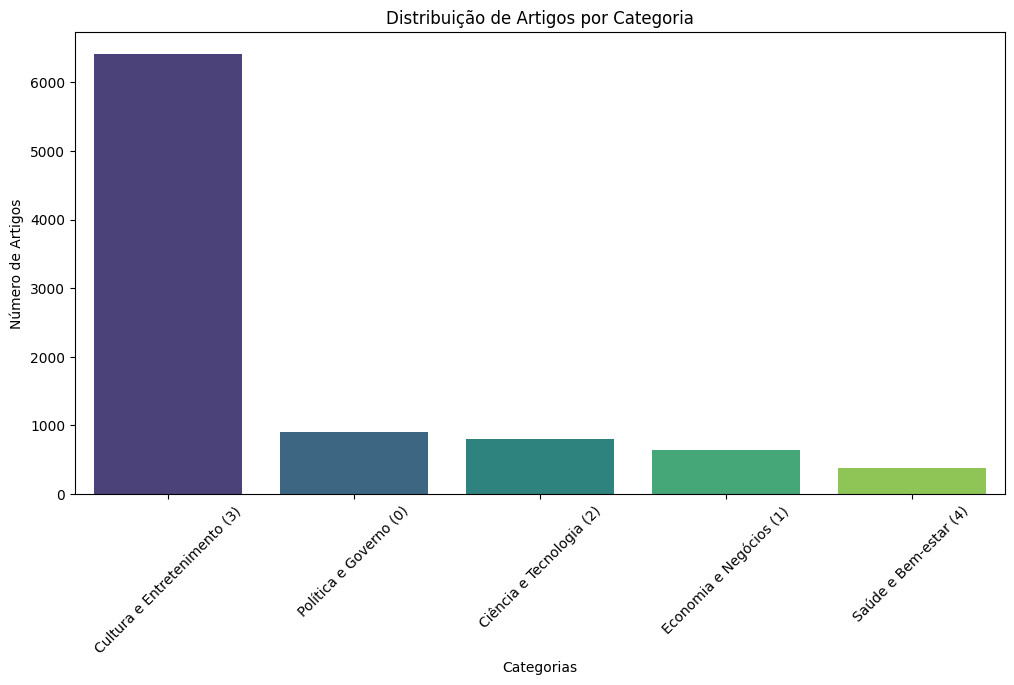

In [ ]:
df['category_name'] = map_cluster_labels(labels)

plot_category_distribution(df)

In [ ]:
def plot_clusters_with_centroids(tfidf_matrix, labels):
    """
    Plota os clusters e seus centróides utilizando a técnica de t-SNE para redução de dimensionalidade.

    Parameters
    ----------
    tfidf_matrix : sparse matrix
        Matriz TF-IDF dos textos processados.
    labels : list
        Lista de etiquetas de clusters.

    Returns
    -------
    None
    """
    tsne = TSNE(n_components=2, random_state=42)
    tsne_results = tsne.fit_transform(tfidf_matrix.toarray())
    df_tsne = pd.DataFrame(tsne_results, columns=['Component 1', 'Component 2'])
    df_tsne['Cluster'] = labels
    df_tsne['Category Name'] = map_cluster_labels(labels)

    # Cria o gráfico scatter com os pontos
    fig = px.scatter(df_tsne, x='Component 1', y='Component 2', color='Category Name', title="Visualização dos Clusters")

    # Calcula centróides dos clusters
    centroids = df_tsne.groupby('Cluster')[['Component 1', 'Component 2']].mean().reset_index()

    # Adiciona centróides ao gráfico como anotações
    for i, row in centroids.iterrows():
        fig.add_annotation(
            x=row['Component 1'],
            y=row['Component 2'],
            text=f"{i}",
            showarrow=True,
            font=dict(
                size=42,
                color="black"
            ),
            align="center",
            arrowhead=2,
            arrowsize=1,
            arrowwidth=2,
            arrowcolor="red"
        )

    # Atualiza propriedades do marcador
    fig.update_traces(marker=dict(size=8, opacity=0.9, line=dict(width=1)))

    fig.update_layout(
        legend=dict(orientation="h", yanchor="bottom", y=-0.2, xanchor="center", x=0.5, title_text=''),
        width=1300,
        height=1100,
        showlegend=True
    )

    fig.show()



In [ ]:
%%time
plot_clusters_with_centroids(tfidf_matrix, labels)

CPU times: user 2min 27s, sys: 647 ms, total: 2min 28s
Wall time: 2min 28s


### 8. **Conclusão**

A comparação entre os três algoritmos de clustering resultou em Silhouette Scores próximos: **Agglomerative (0.0760)**, **KMeans (0.0758)** e **DBSCAN (0.0685)**. O Agglomerative Clustering foi o escolhido por apresentar o maior score, ainda que por margem mínima sobre o KMeans.

É importante ser transparente sobre o que esses números significam: scores nessa faixa (próximos de 0, numa escala de -1 a +1) indicam clusters com separação relativamente fraca entre si. Isso é um resultado esperado ao usar TF-IDF puro — um espaço de alta dimensionalidade e esparso — sobre textos jornalísticos de domínios variados, e não invalida a análise: os grupos formados ainda capturam padrões temáticos reconhecíveis, como confirma a inspeção dos termos mais frequentes por cluster (Seção 9), mas não são compactos e isolados como scores próximos de 1 indicariam.

A visualização com t-SNE ofereceu uma representação gráfica intuitiva dos clusters, facilitando a interpretação dos resultados, e o DBSCAN mostrou as limitações esperadas diante da densidade variável dos dados.

### 9. **Direções Futuras**

**Discussão sobre as melhorias que podem ser implementadas, novos dados que podem ser explorados, ou técnicas adicionais de análise que poderiam ser aplicadas para enriquecer ainda mais o projeto.**

#### Para futuras iterações deste projeto, várias melhorias podem ser consideradas:

1. **Exploração de Mais Dados**: Incluir um conjunto de dados mais amplo ou diversificado pode ajudar a melhorar a robustez dos modelos de clustering e permitir a descoberta de mais padrões únicos.
2. **Utilização de Modelos de PLN Avançados**: Implementar modelos de linguagem mais avançados como BERT ou GPT para pré-processamento de texto poderia melhorar a qualidade das features extraídas e, por consequência, a qualidade dos clusters.
3. **Otimização de Hiperparâmetros**: Realizar uma busca mais sistemática de hiperparâmetros para os algoritmos de clustering poderia levar a resultados ainda melhores.
4. **Análise de Sentimentos**: Integrar análise de sentimentos nos textos pode adicionar uma camada adicional de interpretação aos clusters, especialmente útil em domínios como análise de feedback de clientes ou redes sociais.
5. **Implementação de Clustering Hierárquico**: Experimentar com clustering hierárquico para uma visão em diferentes níveis de granularidade dos dados.


### 10. Referências e Recursos Utilizados

1. **Introdução ao Processamento de Linguagem Natural (PLN)**:
   - [Natural Language Processing with Python](https://www.nltk.org/book/) – Livro que oferece uma introdução prática ao PLN usando Python e a biblioteca NLTK.

2. **Uso de spaCy para Análise de Texto**:
   - [spaCy 101: Everything you need to know](https://spacy.io/usage/spacy-101) – Guia oficial que explica os conceitos fundamentais da biblioteca spaCy para PLN.

3. **Técnicas de Vetorização de Texto – TF-IDF**:
   - [TfidfVectorizer – Scikit-learn Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) – Documentação oficial do Scikit-learn sobre o uso de TF-IDF para vetorização de texto.

4. **Métodos de Clustering e Suas Aplicações**:
   - [Scikit-learn Clustering Techniques](https://scikit-learn.org/stable/modules/clustering.html) – Uma revisão detalhada dos diferentes métodos de clustering disponíveis no Scikit-learn.
   - [DBSCAN Clustering Algorithm: Tutorial and Example](https://towardsdatascience.com/dbscan-clustering-algorithm-what-is-it-when-to-use-it-how-dbscan-works-47b8e8926b6b) – Artigo que fornece uma visão geral do algoritmo DBSCAN e suas aplicações.

5. **Uso de Silhouette Score para Avaliação de Clusters**:
   - [Silhouette Score – Scikit-learn Documentation](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html) – Guia sobre como calcular e interpretar o Silhouette Score para avaliação de clusters.

6. **Redução de Dimensionalidade com t-SNE**:
   - [Visualizing Data using t-SNE – Journal of Machine Learning Research](http://www.jmlr.org/papers/volume9/vandermaaten08a/vandermaaten08a.pdf) – Artigo seminal que introduz a técnica de t-SNE para visualização de dados de alta dimensão.

7. **Guias de Boas Práticas em Machine Learning**:
   - [Google Machine Learning Guides](https://developers.google.com/machine-learning/guides) – Coleção de guias e melhores práticas para desenvolvimento de soluções de machine learning.

8. **Construção e Avaliação de Modelos de Machine Learning**:
   - [Building and Evaluating Models – Machine Learning Mastery](https://machinelearningmastery.com/) – Blog que oferece tutoriais detalhados sobre a construção e avaliação de modelos de machine learning.

9. **Plotly para Visualização de Dados Interativa**:
   - [Plotly Python Graphing Library](https://plotly.com/python/) – Documentação oficial da biblioteca Plotly para Python, útil para criação de visualizações interativas de dados.

10. **Artigos Científicos e Conferências de PLN**:
    - [Association for Computational Linguistics (ACL) Anthology](https://aclanthology.org/) – Um repositório digital de artigos sobre pesquisa em linguística computacional e PLN.

11.  **Breaking news**:

    - [Unveiling a new dataset for Portuguese news classification and comparative analysis of approaches](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0296929) - Metodo de download e extração de dados.